In [1]:
# Install required package for Excel files

%pip install --upgrade openpyxl


You should consider upgrading via the 'C:\Users\Adithya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


# E-Commerce Dataset Analysis
## Exploratory Data Analysis

**Dataset:** E Commerce Dataset.xlsx  
**Date:** February 2026  
**Objective:** Analyze customer behavior, purchase patterns, and retention metrics

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 2. Load Dataset

In [3]:
# Inspect the Excel file structure
xl_file = pd.ExcelFile('E Commerce Dataset.xlsx')
print(f" Sheet names in the workbook: {xl_file.sheet_names}\n")

# Load the actual E-Commerce data from the 'E Comm' sheet
print("=" * 80)
print("Loading E-Commerce Data...")
print("=" * 80)

df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')

print(f" Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

 Sheet names in the workbook: ['Data Dict', 'E Comm']

Loading E-Commerce Data...
 Dataset loaded successfully!
Shape: 5,630 rows × 20 columns

First 5 rows of the dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


## 3. Initial Data Exploration

In [4]:
# Dataset information
print("="*80)
print("DATASET INFORMATION")
print("="*80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13

In [5]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
df.describe(include='all').T

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,"5,630.00",NaN,NaN,NaN,"52,815.50","1,625.39","50,001.00","51,408.25","52,815.50","54,222.75","55,630.00"
Churn,"5,630.00",NaN,NaN,NaN,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,"5,366.00",NaN,NaN,NaN,10.19,8.56,0.00,2.00,9.00,16.00,61.00
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,"5,630.00",NaN,NaN,NaN,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,"5,379.00",NaN,NaN,NaN,15.64,8.53,5.00,9.00,14.00,20.00,127.00
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,"5,375.00",NaN,NaN,NaN,2.93,0.72,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,"5,630.00",NaN,NaN,NaN,3.69,1.02,1.00,3.00,4.00,4.00,6.00


In [6]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

print(missing_data[missing_data['Missing_Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Data completeness: {(1 - df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100:.2f}%")

MISSING VALUES ANALYSIS
                                                  Column  Missing_Count  \
DaySinceLastOrder                      DaySinceLastOrder            307   
OrderAmountHikeFromlastYear  OrderAmountHikeFromlastYear            265   
Tenure                                            Tenure            264   
OrderCount                                    OrderCount            258   
CouponUsed                                    CouponUsed            256   
HourSpendOnApp                            HourSpendOnApp            255   
WarehouseToHome                          WarehouseToHome            251   

                             Missing_Percentage  
DaySinceLastOrder                          5.45  
OrderAmountHikeFromlastYear                4.71  
Tenure                                     4.69  
OrderCount                                 4.58  
CouponUsed                                 4.55  
HourSpendOnApp                             4.53  
WarehouseToHome          

In [7]:
# Check data types and unique values
print("="*80)
print("COLUMN DETAILS")
print("="*80)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  - Data Type: {df[col].dtype}")
    print(f"  - Unique Values: {df[col].nunique():,}")
    print(f"  - Missing: {df[col].isnull().sum():,} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
    
    if df[col].nunique() < 20 and df[col].dtype == 'object':
        print(f"  - Sample Values: {df[col].unique()[:5].tolist()}")

COLUMN DETAILS

CustomerID:
  - Data Type: int64
  - Unique Values: 5,630
  - Missing: 0 (0.00%)

Churn:
  - Data Type: int64
  - Unique Values: 2
  - Missing: 0 (0.00%)

Tenure:
  - Data Type: float64
  - Unique Values: 36
  - Missing: 264 (4.69%)

PreferredLoginDevice:
  - Data Type: object
  - Unique Values: 3
  - Missing: 0 (0.00%)
  - Sample Values: ['Mobile Phone', 'Phone', 'Computer']

CityTier:
  - Data Type: int64
  - Unique Values: 3
  - Missing: 0 (0.00%)

WarehouseToHome:
  - Data Type: float64
  - Unique Values: 34
  - Missing: 251 (4.46%)

PreferredPaymentMode:
  - Data Type: object
  - Unique Values: 7
  - Missing: 0 (0.00%)
  - Sample Values: ['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet']

Gender:
  - Data Type: object
  - Unique Values: 2
  - Missing: 0 (0.00%)
  - Sample Values: ['Female', 'Male']

HourSpendOnApp:
  - Data Type: float64
  - Unique Values: 6
  - Missing: 255 (4.53%)

NumberOfDeviceRegistered:
  - Data Type: int64
  - Unique Values: 6
  - M

## 4. Data Cleaning & Preprocessing

In [8]:
# Identify date columns and convert them
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

print("Converting date columns...")
for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f" {col} converted to datetime")
    except:
        print(f" Could not convert {col}")

print(f"\nDate columns identified: {date_columns}")

Converting date columns...

Date columns identified: []


In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

if duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head())

Duplicate rows: 0 (0.00%)


## 5. Univariate Analysis

NUMERICAL COLUMNS ANALYSIS
Numerical columns: ['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']



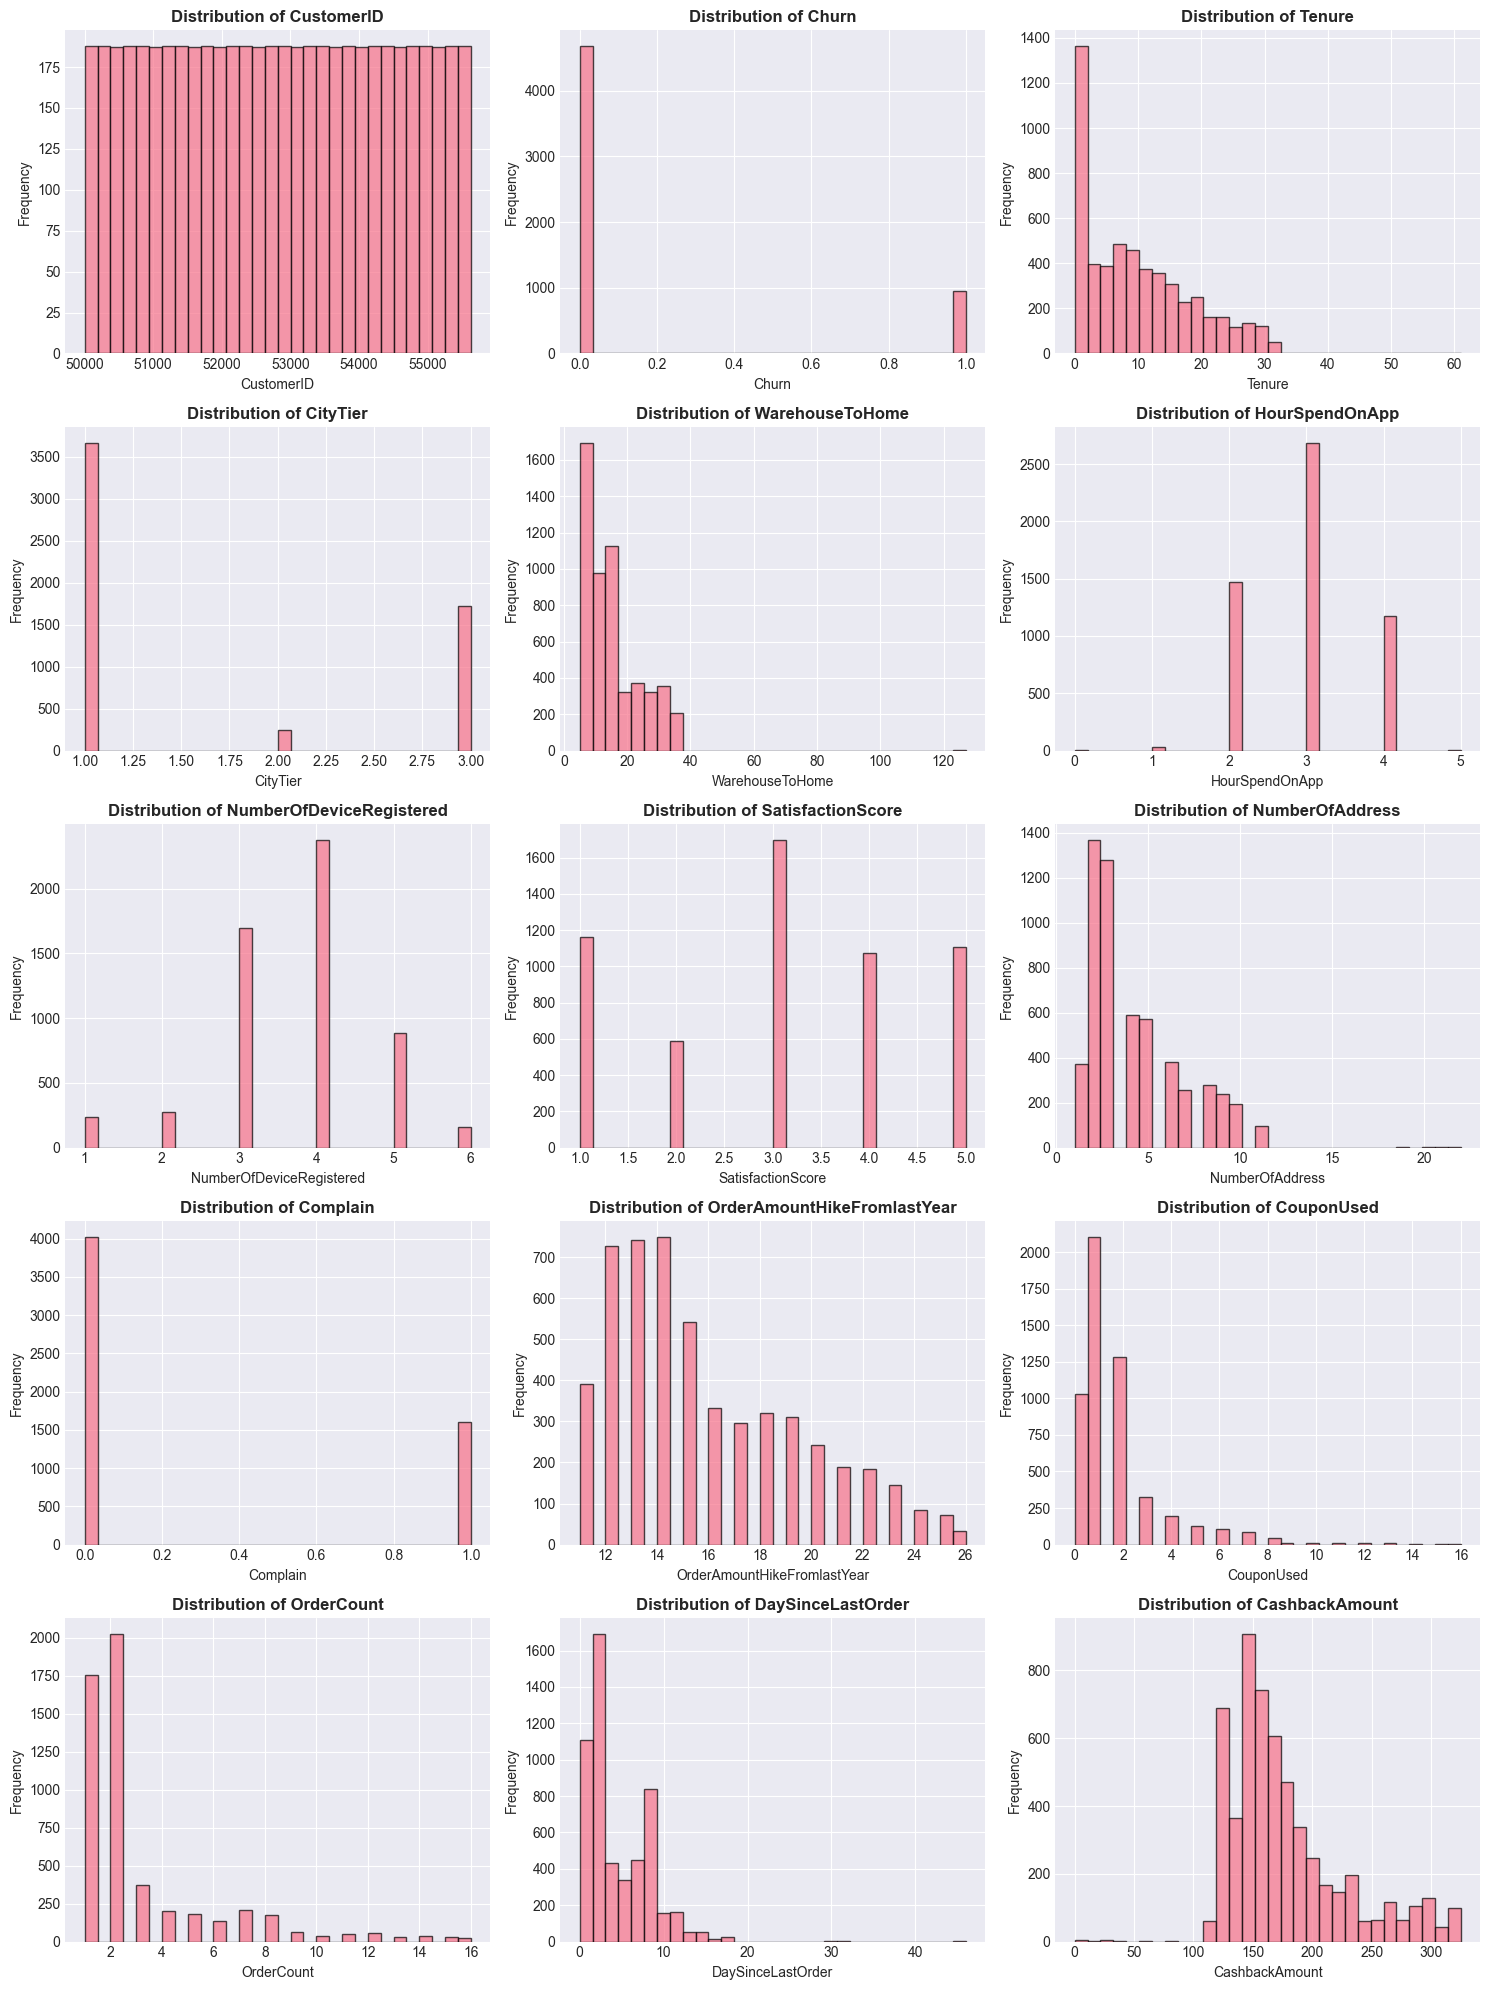

In [10]:
# Analyze numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("="*80)
print("NUMERICAL COLUMNS ANALYSIS")
print("="*80)
print(f"Numerical columns: {numerical_cols}\n")

if len(numerical_cols) > 0:
    # Plot distributions
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            df[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [11]:
# Analyze categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("CATEGORICAL COLUMNS ANALYSIS")
print("="*80)
print(f"Categorical columns: {categorical_cols}\n")

for col in categorical_cols:
    if df[col].nunique() < 50:  # Only show for columns with fewer categories
        print(f"\n{col} - Value Counts:")
        print(df[col].value_counts().head(10))
        print(f"Unique values: {df[col].nunique()}")

CATEGORICAL COLUMNS ANALYSIS
Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


PreferredLoginDevice - Value Counts:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
Unique values: 3

PreferredPaymentMode - Value Counts:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
Unique values: 7

Gender - Value Counts:
Gender
Male      3384
Female    2246
Name: count, dtype: int64
Unique values: 2

PreferedOrderCat - Value Counts:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
Unique values: 6

MaritalStatus - Value Counts:
MaritalStatus
Marrie

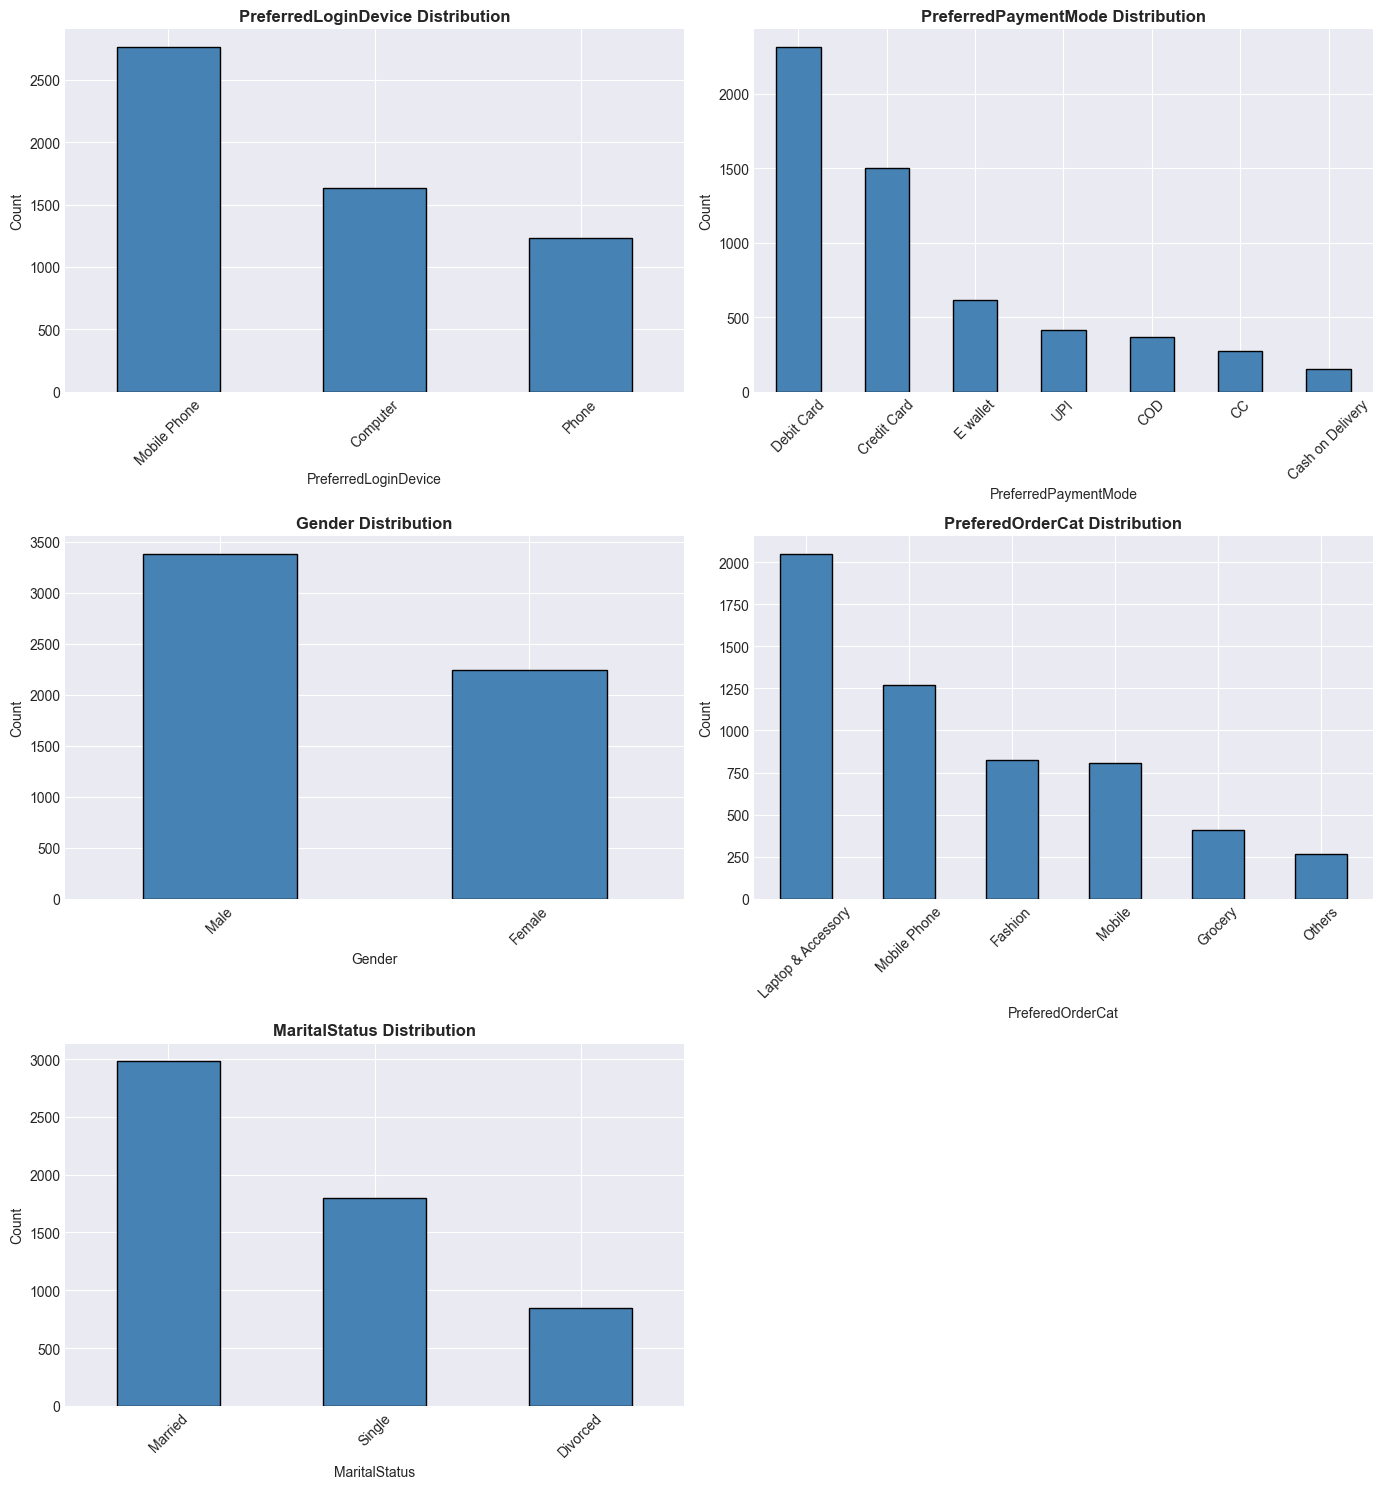

In [12]:
# Visualize top categorical variables
categorical_to_plot = [col for col in categorical_cols if df[col].nunique() < 15]

if len(categorical_to_plot) > 0:
    n_cols = min(2, len(categorical_to_plot))
    n_rows = (len(categorical_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if len(categorical_to_plot) > 1 else [axes]
    
    for idx, col in enumerate(categorical_to_plot):
        if idx < len(axes):
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
            axes[idx].set_title(f'{col} Distribution', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Count')
            axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide extra subplots
    for idx in range(len(categorical_to_plot), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Bivariate Analysis

CORRELATION ANALYSIS


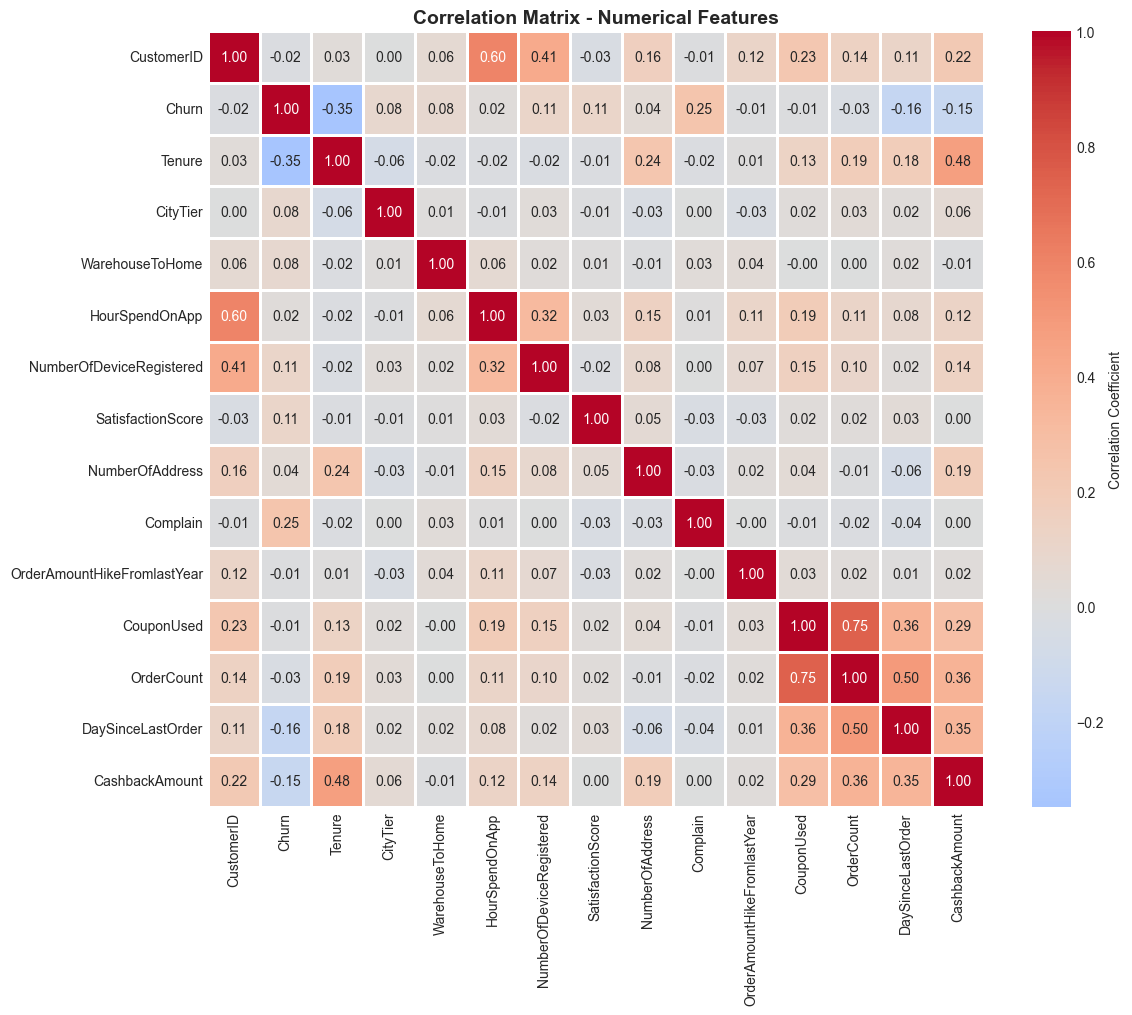


Strong Correlations (|r| > 0.5):
  CustomerID ↔ HourSpendOnApp: 0.598
  CouponUsed ↔ OrderCount: 0.745


In [13]:
# Correlation matrix for numerical variables
if len(numerical_cols) > 1:
    print("="*80)
    print("CORRELATION ANALYSIS")
    print("="*80)
    
    correlation_matrix = df[numerical_cols].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                fmt='.2f', 
                cmap='coolwarm', 
                center=0,
                square=True,
                linewidths=1,
                cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print strong correlations
    print("\nStrong Correlations (|r| > 0.5):")
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                print(f"  {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

## 7. Customer Analysis (if customer ID exists)

 Customer ID column identified: CustomerID

Total unique customers: 5,630
Total transactions: 5,630
Average transactions per customer: 1.00


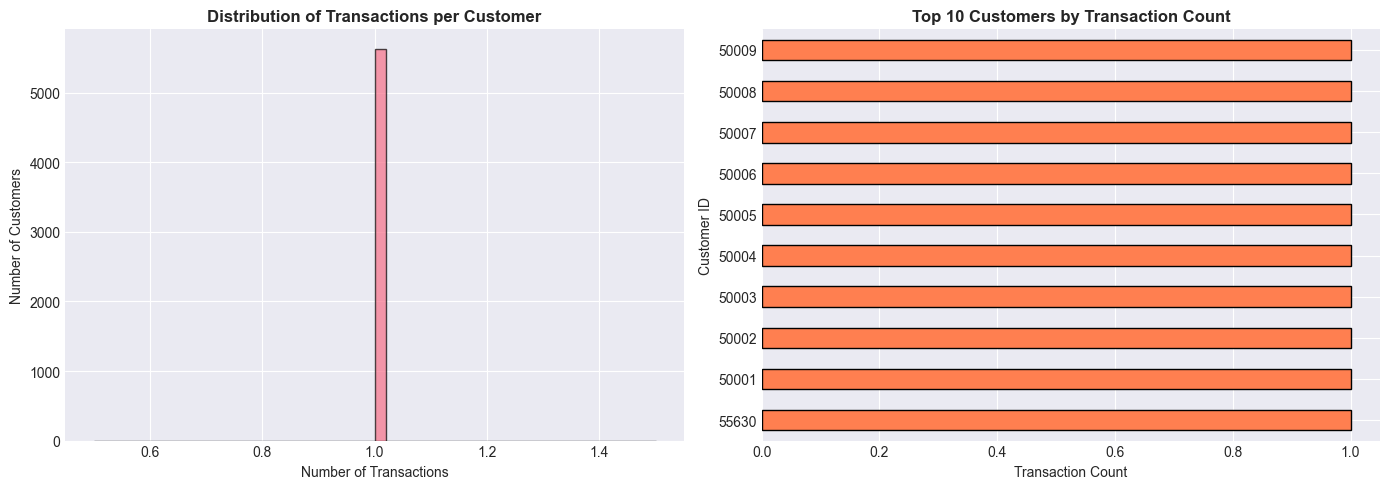

In [14]:
# Try to identify customer ID column
customer_col = None
possible_customer_cols = ['customer_id', 'customerid', 'cust_id', 'user_id', 'userid', 'member_id', 'memberid']

for col in df.columns:
    if col.lower() in possible_customer_cols:
        customer_col = col
        break

if customer_col:
    print(f" Customer ID column identified: {customer_col}")
    print(f"\nTotal unique customers: {df[customer_col].nunique():,}")
    print(f"Total transactions: {len(df):,}")
    print(f"Average transactions per customer: {len(df)/df[customer_col].nunique():.2f}")
    
    # Customer frequency distribution
    customer_freq = df[customer_col].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of transactions per customer
    customer_freq.hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Transactions per Customer', fontweight='bold')
    axes[0].set_xlabel('Number of Transactions')
    axes[0].set_ylabel('Number of Customers')
    
    # Top customers
    customer_freq.head(10).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Top 10 Customers by Transaction Count', fontweight='bold')
    axes[1].set_xlabel('Transaction Count')
    axes[1].set_ylabel('Customer ID')
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ No customer ID column detected")
    print(f"Available columns: {df.columns.tolist()}")

## 8. Temporal Analysis (if date columns exist)

In [15]:
# Analyze temporal patterns
if len(date_columns) > 0:
    for date_col in date_columns:
        if df[date_col].dtype == 'datetime64[ns]':
            print(f"\n{'='*80}")
            print(f"TEMPORAL ANALYSIS - {date_col}")
            print(f"{'='*80}")
            
            # Date range
            print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
            print(f"Total days: {(df[date_col].max() - df[date_col].min()).days} days")
            
            # Extract time features
            df[f'{date_col}_year'] = df[date_col].dt.year
            df[f'{date_col}_month'] = df[date_col].dt.month
            df[f'{date_col}_day'] = df[date_col].dt.day
            df[f'{date_col}_dayofweek'] = df[date_col].dt.dayofweek
            df[f'{date_col}_hour'] = df[date_col].dt.hour
            
            # Plot trends
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Trend over time
            df.groupby(df[date_col].dt.date).size().plot(ax=axes[0,0], color='steelblue')
            axes[0,0].set_title(f'Daily Transactions - {date_col}', fontweight='bold')
            axes[0,0].set_xlabel('Date')
            axes[0,0].set_ylabel('Transaction Count')
            axes[0,0].tick_params(axis='x', rotation=45)
            
            # By month
            df[f'{date_col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
            axes[0,1].set_title('Transactions by Month', fontweight='bold')
            axes[0,1].set_xlabel('Month')
            axes[0,1].set_ylabel('Count')
            
            # By day of week
            day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
            day_counts = df[f'{date_col}_dayofweek'].value_counts().sort_index()
            day_counts.index = [day_names[i] for i in day_counts.index]
            day_counts.plot(kind='bar', ax=axes[1,0], color='lightgreen', edgecolor='black')
            axes[1,0].set_title('Transactions by Day of Week', fontweight='bold')
            axes[1,0].set_xlabel('Day')
            axes[1,0].set_ylabel('Count')
            
            # By hour (if available)
            if df[f'{date_col}_hour'].notna().sum() > 0:
                df[f'{date_col}_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='plum', edgecolor='black')
                axes[1,1].set_title('Transactions by Hour', fontweight='bold')
                axes[1,1].set_xlabel('Hour')
                axes[1,1].set_ylabel('Count')
            else:
                axes[1,1].text(0.5, 0.5, 'No hourly data available', 
                              ha='center', va='center', transform=axes[1,1].transAxes)
                axes[1,1].axis('off')
            
            plt.tight_layout()
            plt.show()
else:
    print(" No date columns detected for temporal analysis")

 No date columns detected for temporal analysis


## 9. Outlier Detection

OUTLIER DETECTION (IQR Method)
                         Column  Outlier_Count  Outlier_Percentage  \
1                         Churn            948               16.84   
12                   OrderCount            703               12.49   
11                   CouponUsed            629               11.17   
14               CashbackAmount            438                7.78   
6      NumberOfDeviceRegistered            397                7.05   
13            DaySinceLastOrder             62                1.10   
10  OrderAmountHikeFromlastYear             33                0.59   
5                HourSpendOnApp              6                0.11   
8               NumberOfAddress              4                0.07   
2                        Tenure              4                0.07   
4               WarehouseToHome              2                0.04   
3                      CityTier              0                0.00   
0                    CustomerID              0             

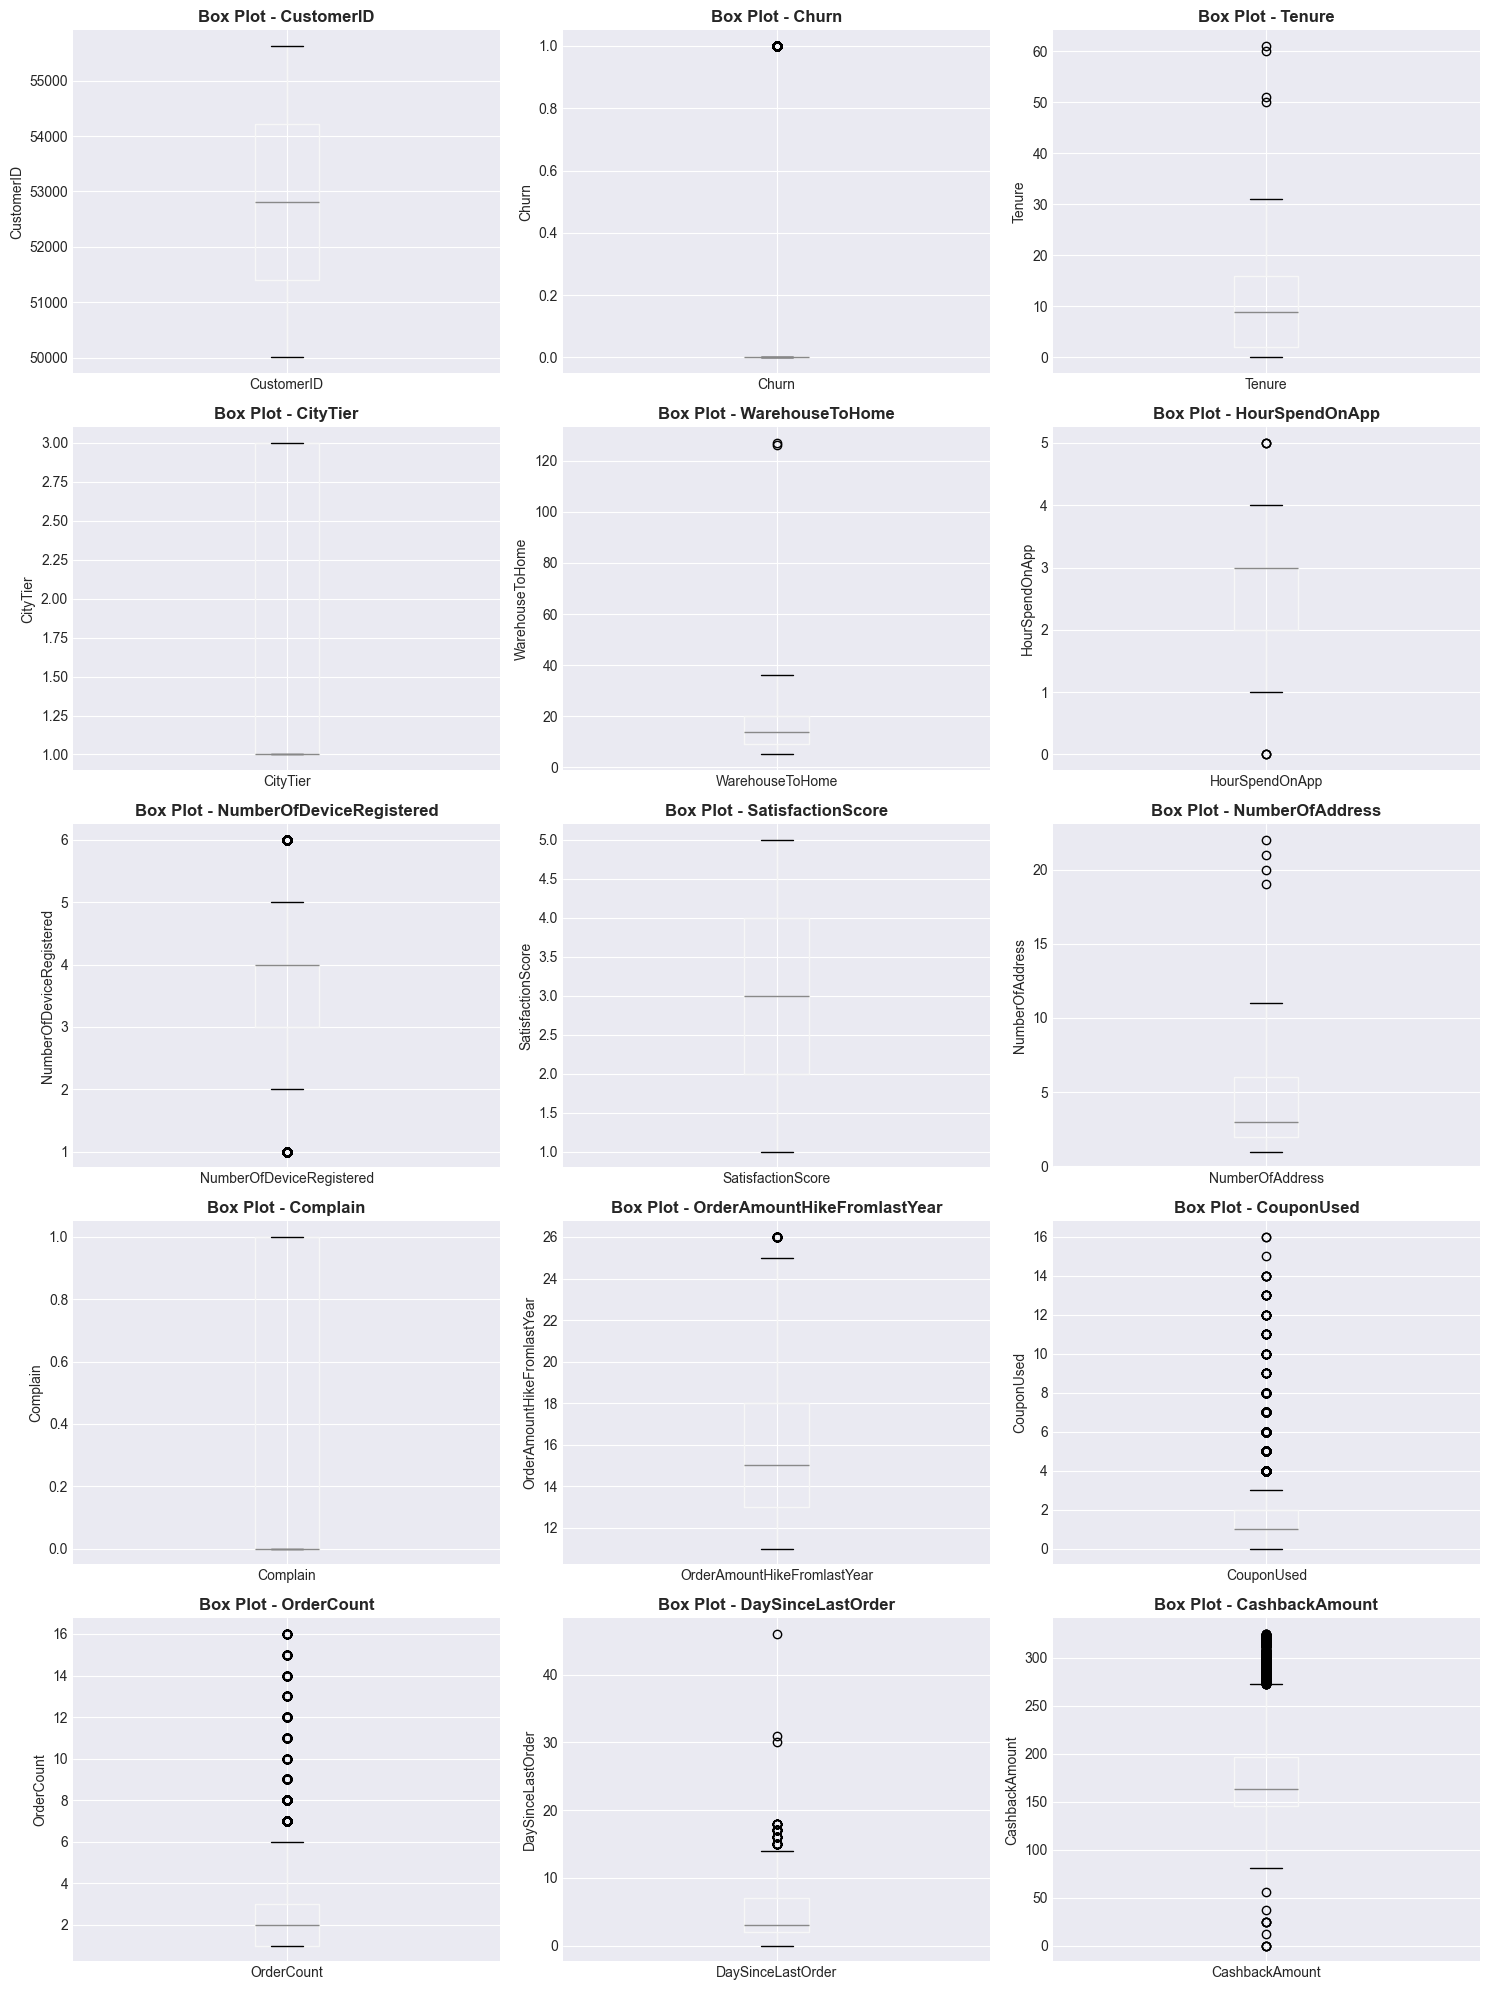

In [16]:
# Detect outliers using IQR method
if len(numerical_cols) > 0:
    print("="*80)
    print("OUTLIER DETECTION (IQR Method)")
    print("="*80)
    
    outlier_summary = []
    
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100
        
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_pct,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
    print(outlier_df)
    
    # Box plots for outlier visualization
    if len(numerical_cols) > 0:
        n_cols = min(3, len(numerical_cols))
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
        
        for idx, col in enumerate(numerical_cols):
            if idx < len(axes):
                df.boxplot(column=col, ax=axes[idx])
                axes[idx].set_title(f'Box Plot - {col}', fontweight='bold')
                axes[idx].set_ylabel(col)
        
        # Hide extra subplots
        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

## 10. Key Insights & Summary

In [17]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)

print(f"\n DATASET OVERVIEW:")
print(f"  • Total Records: {len(df):,}")
print(f"  • Total Features: {df.shape[1]}")
print(f"  • Numerical Features: {len(numerical_cols)}")
print(f"  • Categorical Features: {len(categorical_cols)}")
print(f"  • Date Features: {len(date_columns)}")

if customer_col:
    print(f"\n CUSTOMER METRICS:")
    print(f"  • Unique Customers: {df[customer_col].nunique():,}")
    print(f"  • Avg Transactions per Customer: {len(df)/df[customer_col].nunique():.2f}")

print(f"\n DATA QUALITY:")
total_missing = df.isnull().sum().sum()
completeness = (1 - total_missing/(df.shape[0]*df.shape[1]))*100
print(f"  • Missing Values: {total_missing:,}")
print(f"  • Data Completeness: {completeness:.2f}%")
print(f"  • Duplicate Rows: {df.duplicated().sum():,}")

if len(numerical_cols) > 0:
    print(f"\n NUMERICAL FEATURES:")
    for col in numerical_cols[:5]:  # Show first 5
        print(f"  • {col}:")
        print(f"      - Mean: {df[col].mean():.2f}")
        print(f"      - Median: {df[col].median():.2f}")
        print(f"      - Std Dev: {df[col].std():.2f}")

print(f"\n EDA COMPLETED SUCCESSFULLY!")
print(f"\nNext steps:")
print(f"  1. Feature engineering based on insights")
print(f"  2. Handle missing values and outliers")
print(f"  3. Prepare data for modeling")
print(f"  4. Build predictive models")

EXPLORATORY DATA ANALYSIS SUMMARY

 DATASET OVERVIEW:
  • Total Records: 5,630
  • Total Features: 20
  • Numerical Features: 15
  • Categorical Features: 5
  • Date Features: 0

 CUSTOMER METRICS:
  • Unique Customers: 5,630
  • Avg Transactions per Customer: 1.00

 DATA QUALITY:
  • Missing Values: 1,856
  • Data Completeness: 98.35%
  • Duplicate Rows: 0

 NUMERICAL FEATURES:
  • CustomerID:
      - Mean: 52815.50
      - Median: 52815.50
      - Std Dev: 1625.39
  • Churn:
      - Mean: 0.17
      - Median: 0.00
      - Std Dev: 0.37
  • Tenure:
      - Mean: 10.19
      - Median: 9.00
      - Std Dev: 8.56
  • CityTier:
      - Mean: 1.65
      - Median: 1.00
      - Std Dev: 0.92
  • WarehouseToHome:
      - Mean: 15.64
      - Median: 14.00
      - Std Dev: 8.53

 EDA COMPLETED SUCCESSFULLY!

Next steps:
  1. Feature engineering based on insights
  2. Handle missing values and outliers
  3. Prepare data for modeling
  4. Build predictive models


## 11. Export Processed Data

In [18]:
# Save processed data
output_file = 'processed_ecommerce_data.csv'
df.to_csv(output_file, index=False)

print(f" Processed data exported to: {output_file}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

 Processed data exported to: processed_ecommerce_data.csv
Shape: (5630, 20)
Columns: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


## 12. Preprocess + Train/Test Split

In [27]:
import seaborn as sns
import pandas as pd

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb

# Splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Load dataset (saved earlier as CSV)
df = pd.read_csv("processed_ecommerce_data.csv")
df.shape, df.head()


((5630, 20),
    CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
 0       50001      1    4.00         Mobile Phone         3             6.00   
 1       50002      1     NaN                Phone         1             8.00   
 2       50003      1     NaN                Phone         1            30.00   
 3       50004      1    0.00                Phone         3            15.00   
 4       50005      1    0.00                Phone         1            12.00   
 
   PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
 0           Debit Card  Female            3.00                         3   
 1                  UPI    Male            3.00                         4   
 2           Debit Card    Male            2.00                         4   
 3           Debit Card    Male            2.00                         4   
 4                   CC    Male             NaN                         3   
 
      PreferedOrderCat  Satisfactio

In [28]:
from sklearn.impute import SimpleImputer

X = df.drop("Churn", axis=1)
y = df["Churn"]

cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# Add imputers to handle NaNs before scaling/encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Fit preprocessor on training data to impute/transform, then apply SMOTE
X_train_prep = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)


## Models Training

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        use_label_encoder=False,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(preprocessor.transform(X_test))
    y_proba = model.predict_proba(preprocessor.transform(X_test))[:,1]
    
    results[name] = {
        "Classification Report": classification_report(y_test, y_pred, output_dict=True),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }
    
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\n---------------------------\n")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      1171
           1       0.45      0.81      0.58       237

    accuracy                           0.80      1408
   macro avg       0.70      0.81      0.73      1408
weighted avg       0.87      0.80      0.82      1408

ROC AUC: 0.8843031488828114

---------------------------

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1171
           1       0.77      0.84      0.80       237

    accuracy                           0.93      1408
   macro avg       0.87      0.90      0.88      1408
weighted avg       0.93      0.93      0.93      1408

ROC AUC: 0.8958948138379329

---------------------------

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1171
           1       0.90      0.80      0.85      

In [33]:
import pandas as pd
import numpy as np

rows = []

for name, res in results.items():
    report = res["Classification Report"]
    roc_auc = res["ROC AUC"]

    # Using "1" as the positive class label (common for churn=1)
    # If your churn labels are strings, adjust "1" accordingly.
    pos = report["1"]

    rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": pos["precision"],
        "Recall": pos["recall"],
        "F1 Score": pos["f1-score"],
        "ROC AUC": roc_auc
    })

metrics_df = pd.DataFrame(rows)

# Sort by ROC-AUC (descending), then F1 as tie-breaker
metrics_df = metrics_df.sort_values(by=["ROC AUC", "F1 Score"], ascending=False)

print("Model Performance Comparison:")
display(metrics_df.round(4))


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
7,XGBoost,0.96,0.92,0.86,0.89,0.99
2,Random Forest,0.95,0.90,0.80,0.85,0.99
4,KNN,0.84,0.52,0.92,0.66,0.95
3,SVM (RBF),0.90,0.67,0.84,0.74,0.95
6,Gradient Boosting,0.91,0.72,0.73,0.73,0.93
1,Decision Tree,0.93,0.77,0.84,0.80,0.90
0,Logistic Regression,0.80,0.45,0.81,0.58,0.88
5,Naive Bayes,0.57,0.25,0.81,0.39,0.75


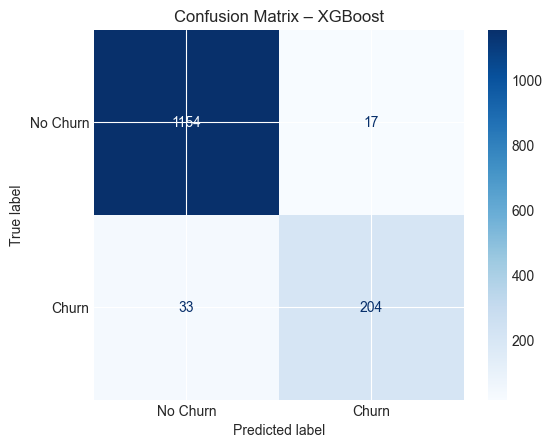

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure we have a fitted XGBoost pipeline named best_xgb that expects preprocessed input
# Create and fit if not present
if 'best_xgb' not in globals():
    best_xgb = Pipeline([
        ('xgb_clf', xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            use_label_encoder=False,
            random_state=42
        ))
    ])
    # X_train_res is preprocessed & resampled; fit the XGB on that data
    best_xgb.fit(X_train_res, y_train_res)

# Transform test set
X_test_proc = preprocessor.transform(X_test)

# Predict
y_pred_xgb = best_xgb.predict(X_test_proc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix – XGBoost")
plt.show()


## Feature Importance from Xgboost


In [36]:
import pandas as pd

# Extract model from pipeline
xgb_model = best_xgb.named_steps["xgb_clf"]

# Get gain importance
importance_dict = xgb_model.get_booster().get_score(importance_type="gain")

feat_imp_gain = (
    pd.DataFrame({
        "Feature": importance_dict.keys(),
        "Importance": importance_dict.values()
    })
    .sort_values("Importance", ascending=False)
)

print("Top 10 XGBoost Feature Importances (Gain):")
display(feat_imp_gain.head(10))


Top 10 XGBoost Feature Importances (Gain):


,Feature,Importance
1,f1,24.86
29,f29,19.73
33,f33,13.95
26,f26,13.25
8,f8,12.47
34,f34,11.73
18,f18,10.22
28,f28,9.59
20,f20,8.61
5,f5,7.40


In [38]:
import re

# Get the fitted preprocessor.
from sklearn.pipeline import Pipeline
if 'best_xgb' in globals() and isinstance(best_xgb, Pipeline) and 'preprocessor' in best_xgb.named_steps:
    pre = best_xgb.named_steps["preprocessor"]
elif 'preprocessor' in globals():
    pre = preprocessor
else:
    raise KeyError("preprocessor not found: ensure 'preprocessor' is defined or included in the pipeline as 'preprocessor'")

# Build the feature name list in the SAME order as the transformed matrix
num_features = list(pre.transformers_[0][2])

ohe = pre.named_transformers_["cat"].named_steps["encoder"]
cat_input_cols = list(pre.transformers_[1][2])
cat_features = list(ohe.get_feature_names_out(cat_input_cols))

feature_names = num_features + cat_features

# 3) Get gain importance from xgboost (keys are like 'f29')
xgb_model = best_xgb.named_steps["xgb_clf"] if ('best_xgb' in globals() and isinstance(best_xgb, Pipeline)) else xgb_model
importance_dict = xgb_model.get_booster().get_score(importance_type="gain")

# 4) Convert f# -> index -> name
def fkey_to_name(fkey: str) -> str:
    idx = int(re.findall(r"\d+", fkey)[0])  # f29 -> 29
    return feature_names[idx] if idx < len(feature_names) else fkey

feat_imp_gain = (
    pd.DataFrame({
        "Feature_Index": list(importance_dict.keys()),
        "Feature": [fkey_to_name(k) for k in importance_dict.keys()],
        "Importance_Gain": list(importance_dict.values())
    })
    .sort_values("Importance_Gain", ascending=False)
)

print("Top 10 XGBoost Feature Importances (Gain) – Mapped:")
display(feat_imp_gain.head(10))


Top 10 XGBoost Feature Importances (Gain) – Mapped:


,Feature_Index,Feature,Importance_Gain
1,f1,Tenure,24.86
29,f29,PreferedOrderCat_Mobile,19.73
33,f33,MaritalStatus_Married,13.95
26,f26,PreferedOrderCat_Fashion,13.25
8,f8,Complain,12.47
34,f34,MaritalStatus_Single,11.73
18,f18,PreferredPaymentMode_COD,10.22
28,f28,PreferedOrderCat_Laptop & Accessory,9.59
20,f20,PreferredPaymentMode_Credit Card,8.61
5,f5,NumberOfDeviceRegistered,7.40


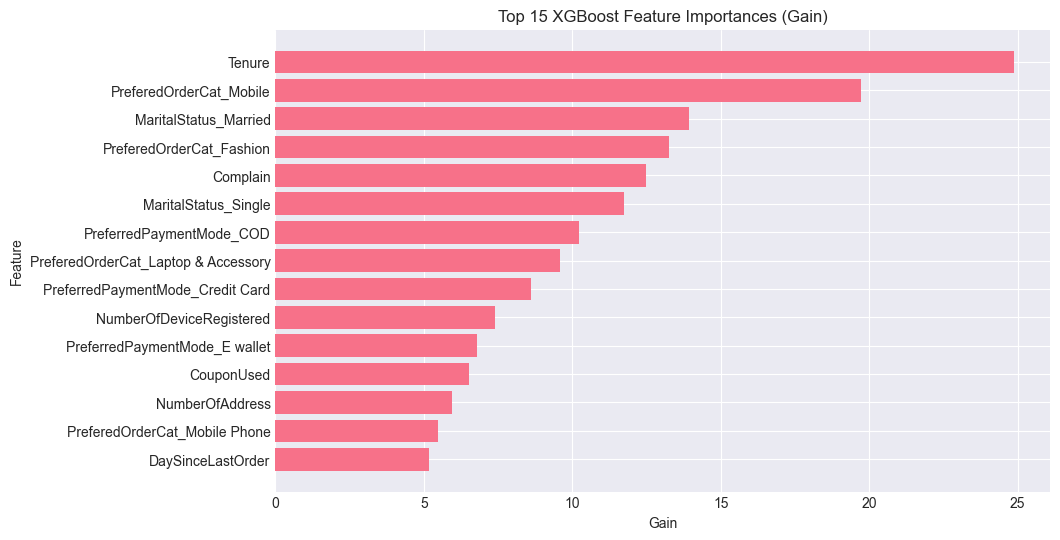

In [39]:
import matplotlib.pyplot as plt

topk = feat_imp_gain.head(15).iloc[::-1]  # reverse for nicer barh
plt.figure(figsize=(10, 6))
plt.barh(topk["Feature"], topk["Importance_Gain"])
plt.title("Top 15 XGBoost Feature Importances (Gain)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.show()


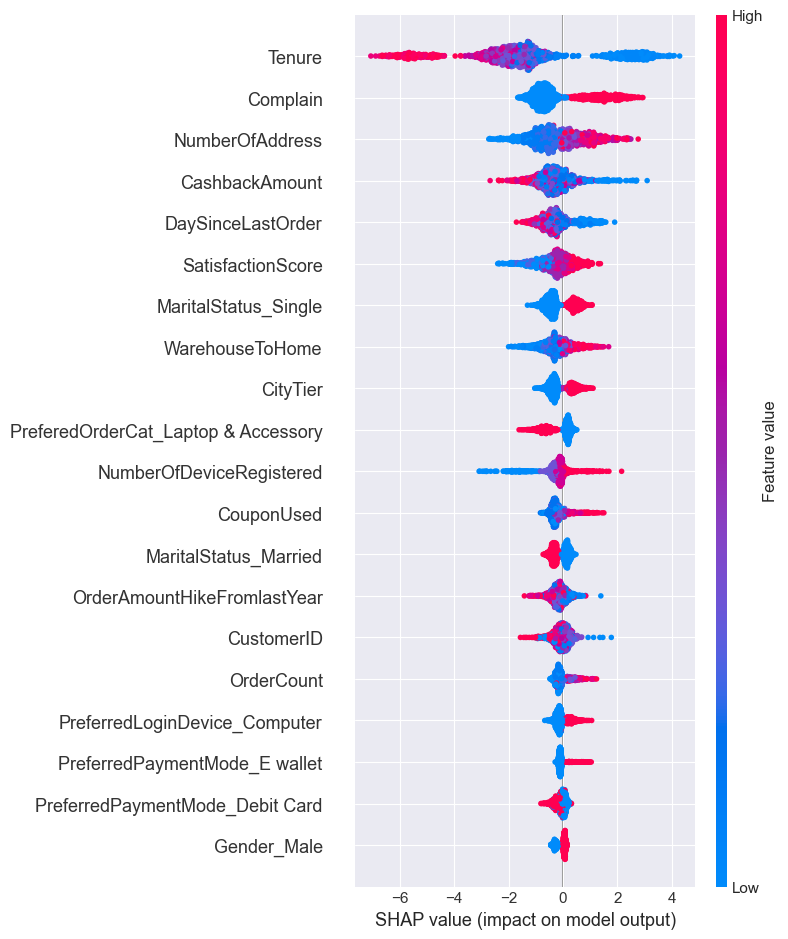

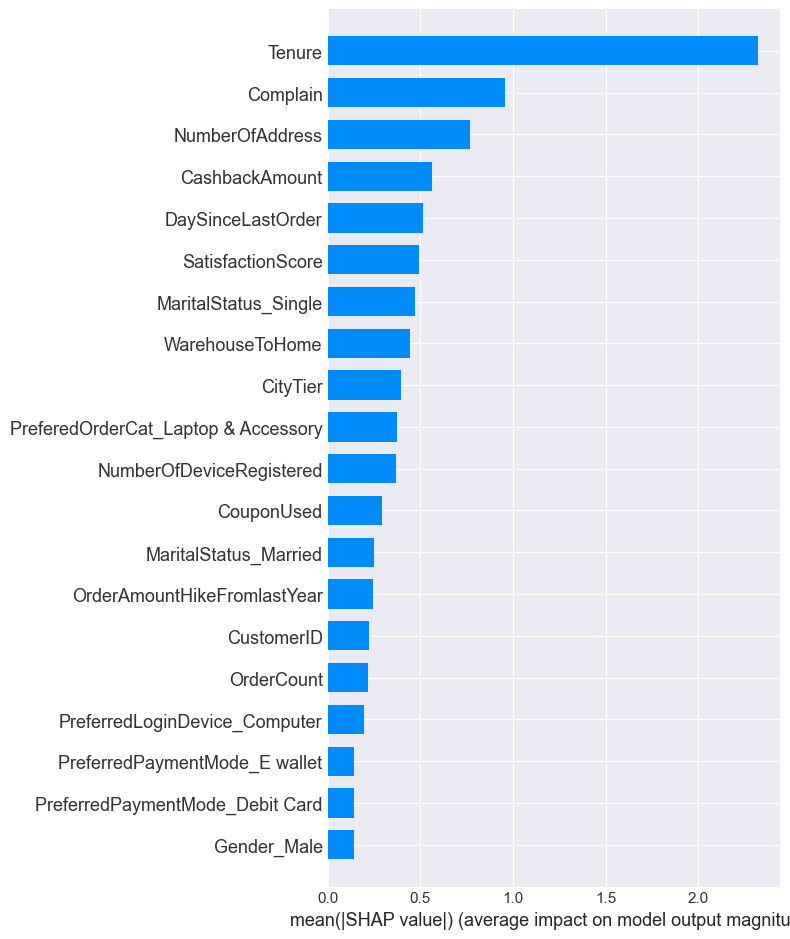

Top 10 features by mean(|SHAP|):


,feature,mean_abs_shap
1,Tenure,2.32
8,Complain,0.96
7,NumberOfAddress,0.77
13,CashbackAmount,0.56
12,DaySinceLastOrder,0.52
6,SatisfactionScore,0.49
34,MaritalStatus_Single,0.47
3,WarehouseToHome,0.45
2,CityTier,0.39
28,PreferedOrderCat_Laptop & Accessory,0.38


<Figure size 800x400 with 0 Axes>

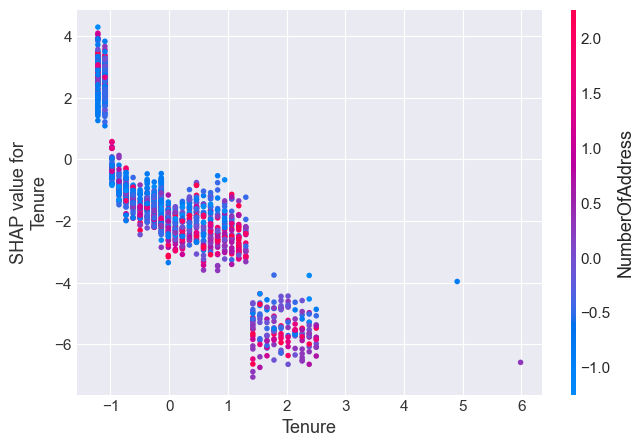

<Figure size 800x400 with 0 Axes>

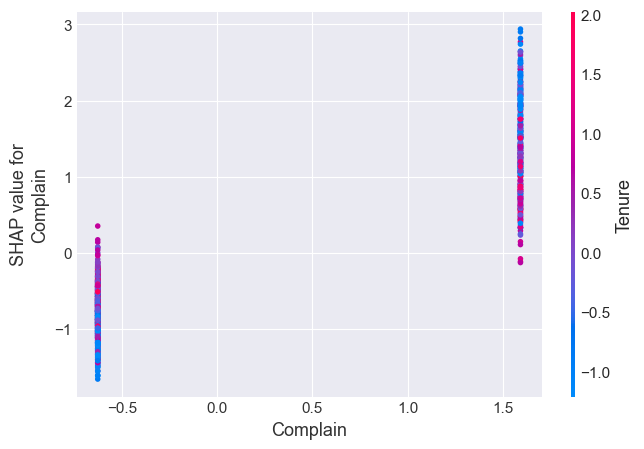

<Figure size 800x400 with 0 Axes>

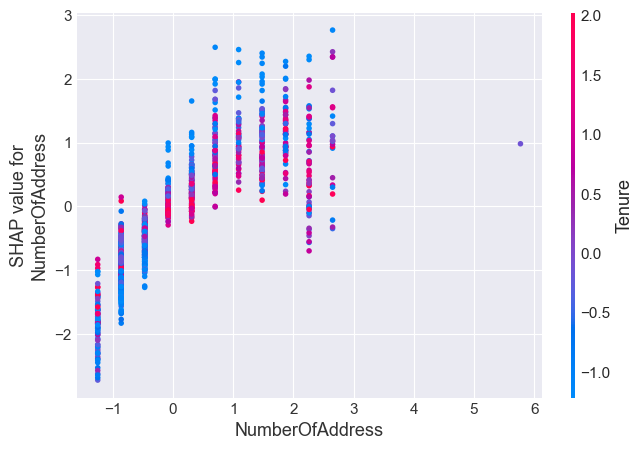

In [41]:
import shap
import sys
import shap
import matplotlib.pyplot as plt

# get fitted xgb model
if 'best_xgb' in globals() and isinstance(best_xgb, Pipeline) and 'xgb_clf' in best_xgb.named_steps:
    model = best_xgb.named_steps['xgb_clf']
elif 'xgb_model' in globals():
    model = xgb_model
else:
    raise KeyError("XGBoost model not found (best_xgb or xgb_model)")

# Ensure test matrix and feature names exist
if 'X_test_proc' not in globals():
    raise KeyError("X_test_proc not found. Run preprocessor.transform(X_test) first.")
if 'feature_names' not in globals():
    raise KeyError("feature_names not found. Build feature_names from preprocessor as in prior cell.")

X = X_test_proc  # numpy array
fnames = feature_names

# Create TreeExplainer and compute SHAP values
explainer = shap.TreeExplainer(model)
shap_vals_raw = explainer.shap_values(X)

# Handle possible list output (binary classification may return [neg, pos])
if isinstance(shap_vals_raw, list):
    # prefer positive-class explanations if available
    shap_vals = shap_vals_raw[-1]
else:
    shap_vals = shap_vals_raw

# Summary plots
plt.figure(figsize=(8,6))
shap.summary_plot(shap_vals, X, feature_names=fnames, show=True)

plt.figure(figsize=(8,6))
shap.summary_plot(shap_vals, X, feature_names=fnames, plot_type="bar", show=True)

# Compute mean absolute SHAP and show top features
mean_abs = np.abs(shap_vals).mean(axis=0)
feat_imp_df = pd.DataFrame({'feature': fnames, 'mean_abs_shap': mean_abs}).sort_values('mean_abs_shap', ascending=False)
print("Top 10 features by mean(|SHAP|):")
display(feat_imp_df.head(10))

# Dependence plots for top 3 features
top_feats = feat_imp_df['feature'].head(3).tolist()
for f in top_feats:
    plt.figure(figsize=(8,4))
    shap.dependence_plot(f, shap_vals, X, feature_names=fnames, show=True)